# 可解釋的AI(eXplainable AI, XAI)

## 載入套件

In [1]:
!pip install shap

In [2]:
import sys
from pathlib import Path
from typing import Sized, cast

import numpy as np
import shap
import torch
from torch import nn, optim
from torch.nn import functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import MNIST

## 檢查 GPU

In [3]:
# 判斷是否為 Colab 環境
is_colab = 'google.colab' in sys.modules
base_path = Path('/content/drive/MyDrive/colab_env') if is_colab else Path('.')
PATH_DATASETS = base_path / "data"  # 預設路徑
device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"
device

'mps'

## 載入 MNIST 手寫阿拉伯數字資料

In [4]:
batch_size = 120
num_epochs = 2

# 下載 MNIST 手寫阿拉伯數字 訓練資料
train_ds = MNIST(PATH_DATASETS, train=True, download=True, transform=transforms.ToTensor())

# 下載測試資料
test_ds = MNIST(PATH_DATASETS, train=False, download=True, transform=transforms.ToTensor())

# 訓練/測試資料的維度
print(train_ds.data.shape, test_ds.data.shape)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=True)

torch.Size([60000, 28, 28]) torch.Size([10000, 28, 28])


## 建立模型

In [5]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 10, kernel_size=5),
            nn.MaxPool2d(2),
            nn.ReLU(),
            nn.Conv2d(10, 20, kernel_size=5),
            nn.Dropout(),
            nn.MaxPool2d(2),
            nn.ReLU(),
        )
        self.fc_layers = nn.Sequential(
            nn.Linear(320, 50),
            nn.ReLU(),
            nn.Dropout(),
            nn.Linear(50, 10),
            nn.Softmax(dim=1),
        )

    def forward(self, x: torch.Tensor):
        x = self.conv_layers(x)
        x = x.view(-1, 320)
        x = self.fc_layers(x)
        return x


model = Net().to(device)

## 定義訓練/測試函數

In [6]:
# 訓練函數
def train(
    model: nn.Module,
    device: str,
    train_loader: DataLoader,
    optimizer: optim.Optimizer,
    epoch: int,
) -> None:
    model.train()
    data: torch.Tensor
    target: torch.Tensor
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output: torch.Tensor = model(data)
        loss = F.nll_loss(output.log(), target)
        loss.backward()
        optimizer.step()
        if batch_idx % 100 == 0:
            batch = (batch_idx + 100) * len(data)
            data_count = len(cast(Sized, train_loader.dataset))
            print(
                f'Train Epoch: {epoch} [{batch}/{data_count} ({(100.0 * batch / data_count):.0f}%)]\tLoss: {loss.item():.6f}'
            )


# 測試函數
def test(model: nn.Module, device: str, test_loader: DataLoader) -> None:
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        data: torch.Tensor
        target: torch.Tensor
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output: torch.Tensor = model(data)
            test_loss += F.nll_loss(output.log(), target).item()
            pred = output.max(1, keepdim=True)[1]
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(cast(Sized, test_loader.dataset))
    print(
        '\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
            test_loss,
            correct,
            len(cast(Sized, test_loader.dataset)),
            100.0 * correct / len(cast(Sized, test_loader.dataset)),
        )
    )

## 訓練

In [7]:
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.5)

for epoch in range(1, num_epochs + 1):
    train(model, device, train_loader, optimizer, epoch)
    test(model, device, test_loader)

Train Epoch: 1 [12000/60000 (20%)]	Loss: 2.308288
Train Epoch: 1 [24000/60000 (40%)]	Loss: 2.225467
Train Epoch: 1 [36000/60000 (60%)]	Loss: 1.440641
Train Epoch: 1 [48000/60000 (80%)]	Loss: 0.897743
Train Epoch: 1 [60000/60000 (100%)]	Loss: 0.879246

Test set: Average loss: 0.0048, Accuracy: 8913/10000 (89%)

Train Epoch: 2 [12000/60000 (20%)]	Loss: 0.546253
Train Epoch: 2 [24000/60000 (40%)]	Loss: 0.751738
Train Epoch: 2 [36000/60000 (60%)]	Loss: 0.635815
Train Epoch: 2 [48000/60000 (80%)]	Loss: 0.556353
Train Epoch: 2 [60000/60000 (100%)]	Loss: 0.538023

Test set: Average loss: 0.0029, Accuracy: 9284/10000 (93%)



## 計算 Shapley Values 

In [8]:
# 以前面 100 筆為背景值， 計算 Shapley Value
batch = next(iter(test_loader))
images, _ = batch
images = images.to(device)

background = images[:100]
test_images = images[100:105]

e = shap.DeepExplainer(model, background)
shap_values = e.shap_values(test_images)

## 繪製5筆測試資料的特徵歸因

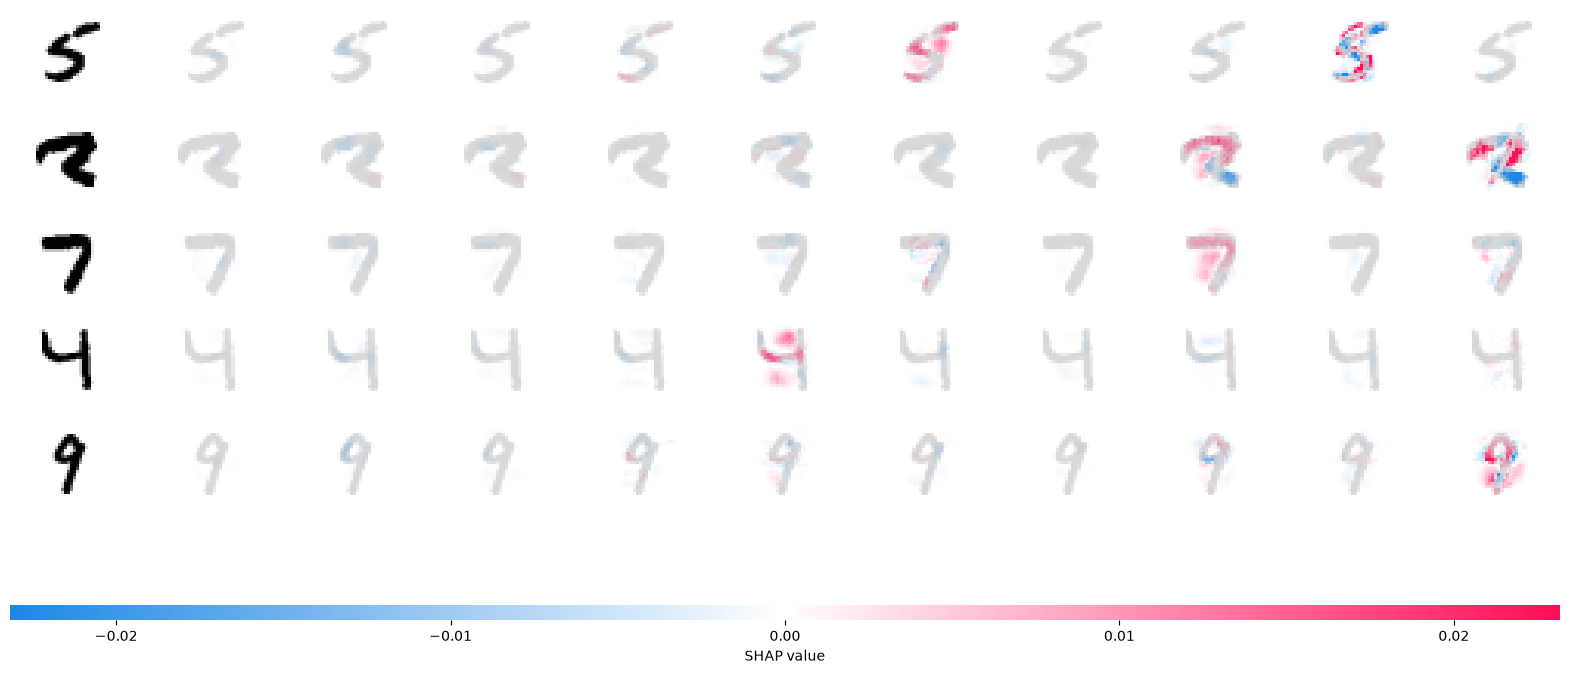

In [9]:
# shap>=0.45 的 DeepExplainer.shap_values() 回傳單一陣列，
# 類別維度疊在最後一軸 (樣本數, C, H, W, 類別數)，故改成對最後一軸取值
assert isinstance(shap_values, np.ndarray)
shap_numpy = [np.swapaxes(np.swapaxes(shap_values[..., i], 1, -1), 1, 2) for i in range(shap_values.shape[-1])]
test_numpy = np.swapaxes(np.swapaxes(test_images.cpu().numpy(), 1, -1), 1, 2)

# plot the feature attributions
shap.image_plot(shap_numpy, -test_numpy)